# PyLandscape - tutorial
Tutorial about the usage of the `pylandscape` package.

## Model preparation

In [1]:
import os
import sys
from os.path import join
from tqdm import tqdm
import time

from pathlib import Path

p = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()

while not (p / "PyLandscape").exists():   # or any marker file
    if p.parent == p:
        raise RuntimeError("Project root not found")
    p = p.parent

os.chdir(os.path.join(p, "PyLandscape"))
print("CWD set to project root:", p)

import numpy as np

#torch
import torch; print('\nPyTorch version in use:', torch.__version__, '\ncuda avail: ', torch.cuda.is_available())
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import transforms, datasets

# others
from copy import deepcopy
from tqdm.autonotebook import tqdm

import brevitas.nn as qnn
import json


CWD set to project root: /home/t.baldi

PyTorch version in use: 2.10.0+cu128 
cuda avail:  True


/tmp/ipykernel_1965889/1238808412.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda:0


In [3]:
name = "cifar10_mobilenetv2_x1_0"

model = torch.hub.load("chenyaofo/pytorch-cifar-models", name, pretrained=True)
if name == "repvgg":
    model.convert_to_inference_model()


Using cache found in /home/t.baldi/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [4]:
BATCH_SIZE = 8
CIFAR10_mean = [0.49139968, 0.48215841, 0.44653091]
CIFAR10_std = [0.2023, 0.1994, 0.2010]

class cifar10(datasets.CIFAR10):
    def __init__(
         self,
         root: str, 
         download: bool = True,
         train: bool = True, 
         center: bool = True, 
         rescale: bool = True, 
         augment: bool = True
     ) -> None:
        
        mean = CIFAR10_mean if center else [0., 0., 0.]
        std = CIFAR10_std if rescale else [1., 1., 1.]
        
        transf_list = [transforms.ToTensor(), transforms.Normalize(mean, std)]
        if train and augment:
            transf_list.append(transforms.RandomCrop(32, padding=4))
            transf_list.append(transforms.RandomHorizontalFlip())

        transform = transforms.Compose(transf_list)
        super().__init__(root=root, train=train, transform=transform, download=download)
        
        

# prepare the dataloader
train_dataset = cifar10("./data", download=True, train=True)
val_dataset = cifar10("./data", download=True, train=False)
    
train_dl = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=True
)
val_dl = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
    pin_memory=True
)

In [5]:
def calculate_accuracy(prediction, targets):
    num_correct = torch.eq(targets, prediction).sum().item()
    total_pred = len(targets)
    correct_percentage = num_correct / total_pred
    return correct_percentage

In [6]:
from brevitas.export.inference import quant_inference_mode

def validate(net, val_loader, loss_function):
    total_correct = 0
    total_samples = 0
    val_losses = []

    net.eval()
    with torch.no_grad(), quant_inference_mode(net):
        for batch_idx, (inputs, labels) in enumerate(tqdm(val_loader, total=len(val_loader))):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = net(inputs)
            loss = loss_function(outputs, labels)
            val_losses.append(loss.item())

            predicted_classes = torch.max(outputs, 1)[1]
            total_correct += (predicted_classes == labels).sum().item()
            total_samples += labels.size(0)

    avg_val_loss = sum(val_losses) / len(val_loader)
    avg_val_accuracy = total_correct / total_samples
    return avg_val_loss, avg_val_accuracy

/home/t.baldi/miniforge3/envs/pyll/lib/python3.11/site-packages/brevitas/graph/equalize.py:69: UserWarning: fast_hadamard_transform package not found, using standard pytorch kernels
  warnings.warn("fast_hadamard_transform package not found, using standard pytorch kernels")


In [7]:
model.to(device)

loss_function = nn.CrossEntropyLoss()

def training(net, train_loader, val_loader, loss_function, epochs, lr=3e-4):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    train_loss_hist, train_acc_hist = [], []
    val_loss_hist, val_acc_hist = [], []

    start_ts = time.time()

    for epoch in range(epochs):
        net.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for inputs, labels in progress:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = net(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            progress.set_postfix(
                loss=total_loss / (total_samples / labels.size(0)),
                acc=total_correct / total_samples
            )

        avg_train_loss = total_loss / len(train_loader)
        avg_train_acc = total_correct / total_samples

        val_loss, val_acc = validate(net, val_loader, loss_function)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train loss: {avg_train_loss:.4f}, acc: {avg_train_acc:.4f} | "
            f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
        )

        train_loss_hist.append(avg_train_loss)
        train_acc_hist.append(avg_train_acc)
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

    print(f"Training time: {time.time() - start_ts:.1f}s")
    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist



In [8]:
net_copy = deepcopy(model)    
net_copy.to(device)

MobileNetV2(
  (features): Sequential(
    (0): ConvBNActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): ConvBNActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): ConvBNActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momen

In [9]:
from brevitas.graph.quantize import preprocess_for_quantize
from brevitas.graph.quantize import quantize
from brevitas import nn as qnn
from brevitas.quant import (
  Int8ActPerTensorFloat,
  Int8WeightPerTensorFloat,
  Int32Bias,
  Uint8ActPerTensorFloat,
)
from copy import deepcopy
from typing import *
from torch import nn


class QuantConfigFactory:
    def __init__(
        self,
        weight_quant = Int8WeightPerTensorFloat,
        act_quant_signed = Int8ActPerTensorFloat,
        act_quant_unsigned = Uint8ActPerTensorFloat,
        bias_quant = Int32Bias,
        bit_width: int = 8,
    ) -> None:
        self.bit_width = bit_width
        self.weight_quant = weight_quant
        self.act_quant_signed = act_quant_signed
        self.act_quant_unsigned = act_quant_unsigned
        self.bias_quant = bias_quant

    @property
    def compute_layer_map(self) -> Dict:
        return {
            nn.Conv2d: (
                qnn.QuantConv2d,
                {
                    "weight_quant": self.weight_quant,
                    "bias_quant": self.bias_quant,
                    "bias": True,
                    "return_quant_tensor": True,
                    # "output_bit_width": self.bit_width,
                    "weight_bit_width": self.bit_width,
                },
            ),
            nn.Linear: (
                qnn.QuantLinear,
                {
                    "weight_quant": self.weight_quant,
                    "bias_quant": self.bias_quant,
                    "bias": True,
                    "return_quant_tensor": True,
                    # "output_bit_width": self.bit_width,
                    "weight_bit_width": self.bit_width,
                },
            ),
            nn.BatchNorm2d: (
                qnn.BatchNorm2dToQuantScaleBias,
                {
                    "weight_quant": self.weight_quant,
                    "bias_quant": self.bias_quant,
                    "return_quant_tensor": True,
                },
            ),
        }

    @property
    def activation_map(self) -> Dict:
        return {
            nn.ReLU: (
                qnn.QuantReLU,
                {
                    "act_quant": self.act_quant_unsigned,
                    "return_quant_tensor": True,
                    "bit_width": self.bit_width,
                },
            ),
        }

    @property
    def identity_map(self):
        return {
            "signed": (
                qnn.QuantIdentity,
                {
                    "act_quant": self.act_quant_signed,
                    "return_quant_tensor": True,
                    "bit_width": self.bit_width,
                },
            ),
            "unsigned": (
                qnn.QuantIdentity,
                {
                    "act_quant": self.act_quant_unsigned,
                    "return_quant_tensor": True,
                    "bit_width": self.bit_width,
                },
            ),
        }



def quantize_model(model: nn.Module, bit_width: int) -> nn.Module:
    model_copy = deepcopy(model)
    
    # quantize the model
    quant_factory = QuantConfigFactory(bit_width=bit_width)
    gnet = preprocess_for_quantize(model_copy)
    qnet = quantize(
        graph_model=gnet,
        compute_layer_map=quant_factory.compute_layer_map,
        quant_act_map=quant_factory.activation_map,
        quant_identity_map=quant_factory.identity_map,
    )
    
    return qnet


qnet = quantize_model(net_copy, 8)
# Test over validation dataset
loss_function=nn.CrossEntropyLoss()
qnet.to(device)

average_val_loss, average_val_accuracy = validate(qnet, val_dl, loss_function)
# Print valid statistics
print('Validation Loss: %.4f' % (average_val_loss), 'Accuracy: %.4f' % (average_val_accuracy))

  0%|          | 0/1250 [00:00<?, ?it/s]/home/t.baldi/miniforge3/envs/pyll/lib/python3.11/site-packages/torch/_tensor.py:1679: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /pytorch/c10/core/TensorImpl.h:1973.)
  return super().rename(names)
100%|██████████| 1250/1250 [00:18<00:00, 67.37it/s]


Validation Loss: 1.3098 Accuracy: 0.5614


In [10]:
QAT_epochs = 1

# training(qnet, train_dl, val_dl, loss_function, QAT_epochs, lr=1e-5)

# average_val_loss, average_val_accuracy = validate(qnet, val_dl, loss_function)
# # Print valid statistics
# print('Validation Loss: %.4f' % (average_val_loss), 'Accuracy: %.4f' % (average_val_accuracy))

## Surface and Hessian

In [14]:
from pylandscape import surface
metric = surface.Surface(qnet, nn.CrossEntropyLoss(), val_dl, device)

random = metric.random_surface(lams=(-0.5, 0.5), steps=10)
hessian = metric.hessian_surface(lams=(-0.5, 0.5), steps=10, max_iter=5)

(<Figure size 900x700 with 2 Axes>,
 <Axes: title={'center': 'Top Eigenvectors Loss Surface'}, xlabel='α ', ylabel='β '>)

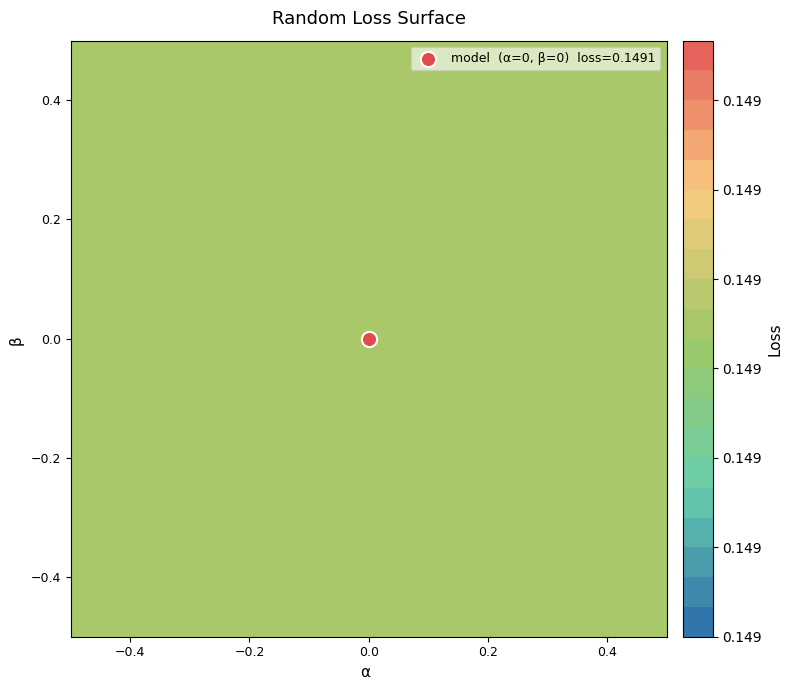

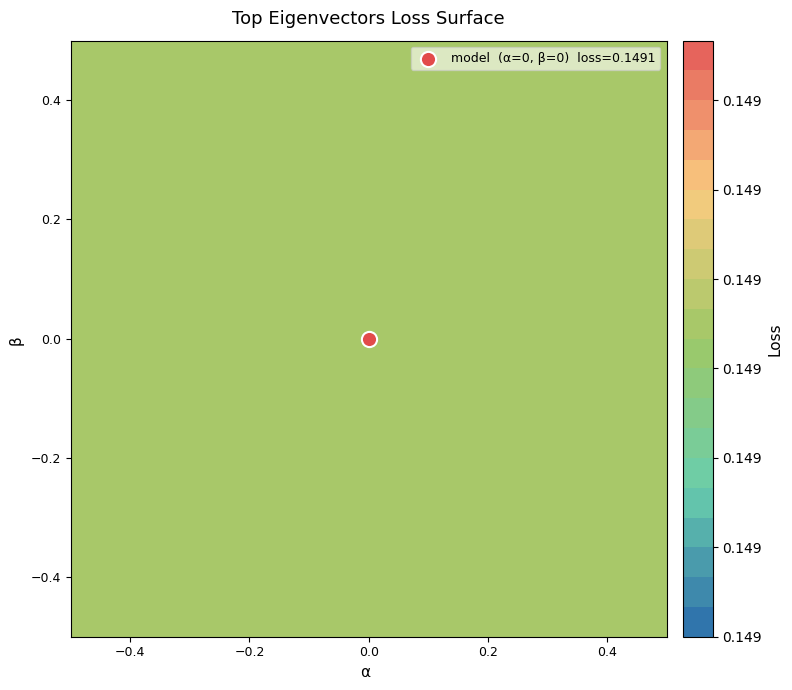

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

def plot_surface(data, figsize=(9, 7), levels=20, cmap=None, title="Loss surface"):

    alpha, beta, loss = data          # 2-D array, shape (steps, steps)

    A, B = np.meshgrid(alpha, beta)     # both (steps, steps)

    # ── colormap ────────────────────────────────────────────────────────────
    if cmap is None:
        cmap = LinearSegmentedColormap.from_list(
            "hessian",
            ["#185FA5", "#5DCAA5", "#97C459", "#FAC775", "#E24B4A"],
        )

    # ── figure ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # filled contours (topographic "elevation" bands)
    cf = ax.contourf(A, B, loss, levels=levels, cmap=cmap, alpha=0.92)

    # iso-loss contour lines
    cs = ax.contour(
        A, B, loss,
        levels=levels,
        colors="white",
        linewidths=0.45,
        alpha=0.45,
    )

    # optional: label a subset of contour lines
    ax.clabel(cs, cs.levels[::3], inline=True, fontsize=7, fmt="%.3f", colors="white")

    # ── colour bar ──────────────────────────────────────────────────────────
    cbar = fig.colorbar(cf, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Loss", fontsize=11)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

    # ── model position marker  (α = 0, β = 0) ───────────────────────────────
    loss_at_model = float(
        loss[np.argmin(np.abs(beta)), np.argmin(np.abs(alpha))]
    )
    ax.scatter(
        0, 0,
        s=120, c="#E24B4A", zorder=5,
        edgecolors="white", linewidths=1.5,
        label=f"model  (α=0, β=0)  loss={loss_at_model:.4f}",
    )

    # ── labels & formatting ─────────────────────────────────────────────────
    ax.set_xlabel("α ", fontsize=11)
    ax.set_ylabel("β ", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.6)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=9)

    plt.tight_layout()
    return fig, ax

plot_surface(random, title="Random Loss Surface")
plot_surface(hessian, title="Top Eigenvectors Loss Surface")

## CKA similarity

In [11]:
from pylandscape import cka

metric = cka.CKA(device)

cka_matrix = metric.compare_models(qnet, qnet, val_dl)
cka_matrix.shape

(0, 0)

In [ ]:
from __future__ import annotations

from typing import List, Optional

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


def plot_cka_matrix(
    cka_matrix: np.ndarray,
    labels_x: Optional[List[str]] = None,
    labels_y: Optional[List[str]] = None,
    title: str = "CKA Similarity",
    mode: str = "cross",          # "cross" | "self"
    figsize: Optional[tuple] = None,
    cmap: Optional[str] = None,
) -> tuple:

    n_y, n_x = cka_matrix.shape

    # ── default labels ────────────────────────────────────────────────────────
    if labels_x is None:
        labels_x = [f"L{i}" for i in range(n_x)]
    if labels_y is None:
        labels_y = [f"L{i}" for i in range(n_y)]

    # ── auto figure size: scale with layer count ──────────────────────────────
    if figsize is None:
        cell = 0.55
        figsize = (max(5, n_x * cell + 2.5), max(4, n_y * cell + 2.0))

    # ── colour map: light blue → deep blue → teal ─────────────────────────────
    if cmap is None:
        cmap = LinearSegmentedColormap.from_list(
            "cka", ["#E6F1FB", "#85B7EB", "#185FA5", "#0F6E56", "#1D9E75"]
        )

    # ── figure & axes ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cka_matrix, aspect="auto", vmin=0, vmax=1, cmap=cmap)

    # ── colour bar ────────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("CKA similarity", fontsize=10)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])


    # ── ticks & labels ────────────────────────────────────────────────────────
    max_label_len = 12
    ax.set_xticks(np.arange(n_x))
    ax.set_yticks(np.arange(n_y))
    ax.set_xticklabels(
        [lbl[:max_label_len] for lbl in labels_x],
        rotation=45, ha="right", fontsize=9,
    )
    ax.set_yticklabels(
        [lbl[:max_label_len] for lbl in labels_y],
        fontsize=9,
    )

    # ── axis & figure titles ──────────────────────────────────────────────────
    if mode == "self":
        ax.set_xlabel("Layer index", fontsize=10)
        ax.set_ylabel("Layer index", fontsize=10)
    else:
        ax.set_xlabel("Model 2 — layers", fontsize=10)
        ax.set_ylabel("Model 1 — layers", fontsize=10)

    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()
    return fig, ax


plot_cka_matrix(cka_matrix, mode="self", title=f"CKA similarity {name}")

KeyboardInterrupt: 